In [1]:
# ============================================================
# CELL 1: Setup and Load Data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import os
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

EDA_DIR = r"..\..\Dissertation_Results\EDA"
os.makedirs(EDA_DIR, exist_ok=True)

print(f"Data: {df.shape[0]:,} rows, {df['ticker'].nunique()} tickers")
print(f"Saving to: {EDA_DIR}\n")


Data: 589,886 rows, 523 tickers
Saving to: ..\..\Dissertation_Results\EDA



In [2]:


# ============================================================
# CELL 2: Text Output — Descriptive Statistics
# ============================================================

print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

stats_vars = ['sentiment', 'log_return', 'volatility_20d', 'next_day_return']
desc = df[stats_vars].describe(percentiles=[0.25, 0.5, 0.75]).T
desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc = desc.round(6)
print(desc.to_string())

# Save as CSV
desc.to_csv(os.path.join(EDA_DIR, "descriptive_statistics.csv"))
print("\nSaved: descriptive_statistics.csv")

DESCRIPTIVE STATISTICS
                    count      mean       std       min       25%       50%       75%       max
sentiment        589886.0 -0.008624  0.324341 -1.000000 -0.084100  0.000000  0.064200  1.000000
log_return       589363.0  0.000360  0.025145 -0.963050 -0.010222  0.000718  0.011478  0.396572
volatility_20d   579426.0  0.021540  0.013159  0.001346  0.013638  0.018264  0.025045  0.287376
next_day_return  589363.0  0.000360  0.025145 -0.963050 -0.010222  0.000718  0.011478  0.396572

Saved: descriptive_statistics.csv


In [3]:
# ============================================================
# CELL 3: Text Output — Target, Coverage, Observations
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"\nTarget Variable:")
print(df['target'].value_counts(normalize=True).round(4).to_string())

non_zero = (df['sentiment'] != 0).sum()
total = len(df)
print(f"\nSentiment Coverage:")
print(f"  Non-zero: {non_zero:,} ({non_zero/total*100:.1f}%)")
print(f"  Zero: {total - non_zero:,} ({(total-non_zero)/total*100:.1f}%)")

obs_per_ticker = df.groupby('ticker').size()
print(f"\nObservations per Ticker:")
print(f"  Mean: {obs_per_ticker.mean():.0f}, Min: {obs_per_ticker.min()}, Max: {obs_per_ticker.max()}")


DATASET SUMMARY

Target Variable:
target
1    0.5173
0    0.4827

Sentiment Coverage:
  Non-zero: 445,229 (75.5%)
  Zero: 144,657 (24.5%)

Observations per Ticker:
  Mean: 1128, Min: 128, Max: 1507


In [4]:
# ============================================================
# CELL 4: Text Output — Correlation Matrix
# ============================================================

print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

corr_vars = ['sentiment', 'log_return', 'volatility_20d', 'next_day_return', 'sent_x_vol', 'market_vol']
corr_matrix = df[corr_vars].corr().round(4)
print(corr_matrix.to_string())

corr_matrix.to_csv(os.path.join(EDA_DIR, "correlation_matrix.csv"))
print("\nSaved: correlation_matrix.csv")


CORRELATION MATRIX
                 sentiment  log_return  volatility_20d  next_day_return  sent_x_vol  market_vol
sentiment           1.0000      0.0563         -0.0038          -0.0046      0.8663      0.0153
log_return          0.0563      1.0000          0.0061          -0.0363      0.0684      0.0202
volatility_20d     -0.0038      0.0061          1.0000           0.0231     -0.0440      0.6504
next_day_return    -0.0046     -0.0363          0.0231           1.0000     -0.0000      0.0297
sent_x_vol          0.8663      0.0684         -0.0440          -0.0000      1.0000      0.0083
market_vol          0.0153      0.0202          0.6504           0.0297      0.0083      1.0000

Saved: correlation_matrix.csv


In [5]:
# ============================================================
# CELL 5: Text Output — Yearly Summary
# ============================================================

print("\n" + "=" * 70)
print("YEARLY SUMMARY")
print("=" * 70)

yearly = df.groupby('year').agg(
    observations=('sentiment', 'count'),
    tickers=('ticker', 'nunique'),
    mean_sentiment=('sentiment', 'mean'),
    mean_volatility=('volatility_20d', 'mean'),
    mean_return=('log_return', 'mean'),
    pct_up=('target', 'mean'),
    pct_nonzero_sent=('sentiment', lambda x: (x != 0).mean())
).round(4)
yearly['pct_up'] = (yearly['pct_up'] * 100).round(1)
yearly['pct_nonzero_sent'] = (yearly['pct_nonzero_sent'] * 100).round(1)
print(yearly.to_string())

yearly.to_csv(os.path.join(EDA_DIR, "yearly_summary.csv"))
print("\nSaved: yearly_summary.csv")


YEARLY SUMMARY
      observations  tickers  mean_sentiment  mean_volatility  mean_return  pct_up  pct_nonzero_sent
year                                                                                               
2020         83756      456          0.0293           0.0344       0.0004    51.6              53.5
2021         90836      472          0.0193           0.0187       0.0012    53.6              58.9
2022        105783      486         -0.0399           0.0231      -0.0007    49.1              88.8
2023        104862      492         -0.0273           0.0177       0.0005    51.8              87.4
2024        105423      499         -0.0164           0.0174       0.0004    52.4              83.9
2025         99226      492         -0.0048           0.0213       0.0004    52.1              73.4

Saved: yearly_summary.csv


In [6]:
# ============================================================
# CELL 6: Text Output — ADF Stationarity Tests
# ============================================================

print("\n" + "=" * 70)
print("ADF STATIONARITY TESTS")
print("=" * 70)

daily_means = df.groupby('date').agg(
    sentiment=('sentiment', 'mean'),
    log_return=('log_return', 'mean'),
    volatility_20d=('volatility_20d', 'mean')
).dropna()

adf_results = []
for col in ['sentiment', 'log_return', 'volatility_20d']:
    adf_stat, p_value, usedlag, nobs, crit_values, icbest = adfuller(daily_means[col], maxlag=20)
    adf_results.append({
        'Variable': col,
        'ADF Statistic': round(adf_stat, 4),
        'p-value': round(p_value, 6),
        '1% Critical': round(crit_values['1%'], 4),
        '5% Critical': round(crit_values['5%'], 4),
        'Stationary': 'Yes' if p_value < 0.05 else 'No'
    })

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))

adf_df.to_csv(os.path.join(EDA_DIR, "adf_stationarity.csv"), index=False)
print("\nSaved: adf_stationarity.csv")


ADF STATIONARITY TESTS
      Variable  ADF Statistic  p-value  1% Critical  5% Critical Stationary
     sentiment        -6.2205 0.000000      -3.4348      -2.8635        Yes
    log_return       -11.2789 0.000000      -3.4348      -2.8635        Yes
volatility_20d        -3.8203 0.002706      -3.4348      -2.8635        Yes

Saved: adf_stationarity.csv


In [7]:
# ============================================================
# CELL 7: Text Output — Sector Summary
# ============================================================

print("\n" + "=" * 70)
print("SECTOR SUMMARY")
print("=" * 70)

sector_file = r"..\..\Data\Main\ticker_sectors.csv"
if os.path.exists(sector_file):
    sectors = pd.read_csv(sector_file)
    df_sec = df.merge(sectors, on='ticker', how='left')
    sector_summary = df_sec.groupby('sector').agg(
        tickers=('ticker', 'nunique'),
        observations=('sentiment', 'count'),
        mean_sentiment=('sentiment', 'mean'),
        mean_volatility=('volatility_20d', 'mean'),
        pct_up=('target', 'mean')
    ).round(4)
    sector_summary['pct_up'] = (sector_summary['pct_up'] * 100).round(1)
    sector_summary = sector_summary.sort_values('tickers', ascending=False)
    print(sector_summary.to_string())
    
    sector_summary.to_csv(os.path.join(EDA_DIR, "sector_summary.csv"))
    print("\nSaved: sector_summary.csv")
else:
    print("No sector file found. Skipping.")


SECTOR SUMMARY
                        tickers  observations  mean_sentiment  mean_volatility  pct_up
sector                                                                                
Technology                   82         86672          0.0006           0.0243    52.3
Industrials                  74         80359         -0.0050           0.0210    51.9
Financial Services           71         81963         -0.0059           0.0204    52.4
Consumer Cyclical            67         73561         -0.0052           0.0249    51.0
Healthcare                   63         72940         -0.0150           0.0205    51.3
Consumer Defensive           37         45403         -0.0091           0.0167    51.4
Real Estate                  32         33368         -0.0201           0.0205    51.3
Utilities                    31         35132         -0.0221           0.0170    52.4
Energy                       22         25544         -0.0018           0.0264    51.6
Basic Materials            

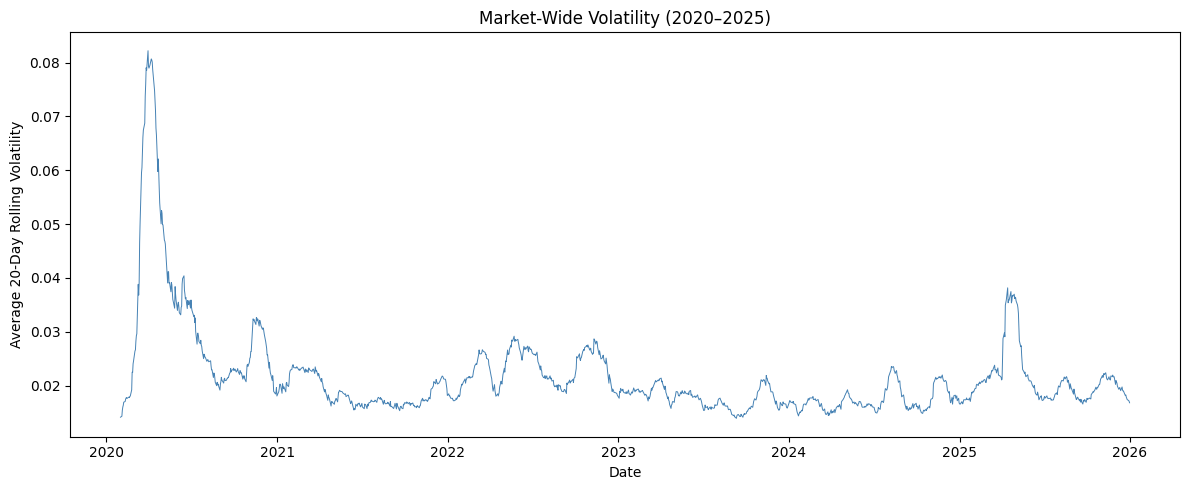

Saved: Fig_Volatility_Over_Time.png


In [8]:
# ============================================================
# CELL 8: FIGURE 1 — Market-Wide Volatility Over Time (YES)
# ============================================================

market_vol = df.dropna(subset=['market_vol']).groupby('date')['market_vol'].first()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(market_vol.index, market_vol.values, linewidth=0.7, color='steelblue')
ax.set_title('Market-Wide Volatility (2020–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Average 20-Day Rolling Volatility')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "Fig_Volatility_Over_Time.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig_Volatility_Over_Time.png")

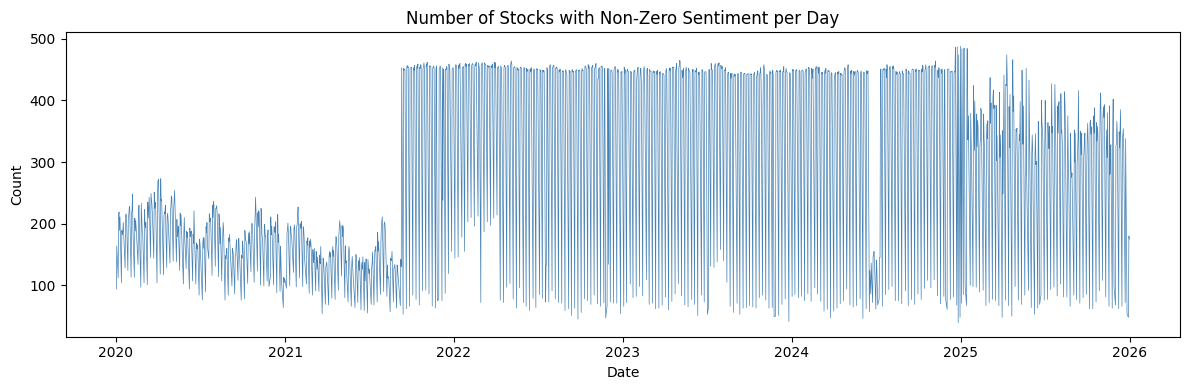

Saved: Fig_Sentiment_Coverage.png


In [9]:
# ============================================================
# CELL 9: FIGURE 2 — Bloomberg Coverage Over Time (YES)
# ============================================================

daily_counts = df[df['sentiment'] != 0].groupby('date')['ticker'].count()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_counts.index, daily_counts.values, linewidth=0.5, color='steelblue')
ax.set_title('Number of Stocks with Non-Zero Sentiment per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "Fig_Sentiment_Coverage.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig_Sentiment_Coverage.png")

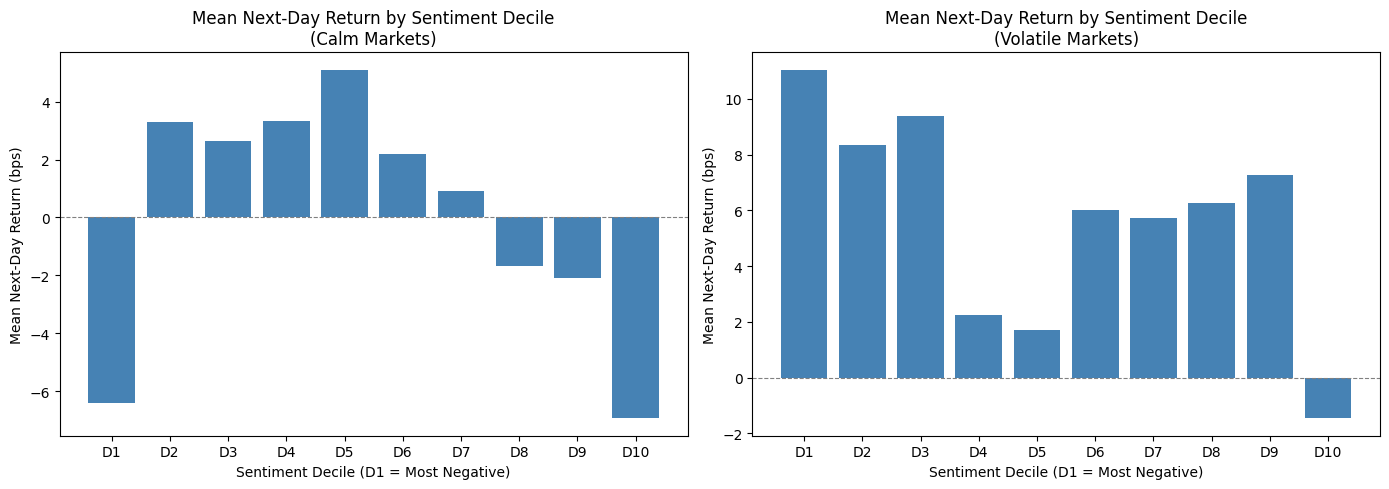

Saved: Fig_Sentiment_Return_By_Regime.png


In [10]:
# ============================================================
# CELL 10: FIGURE 3 — Sentiment-Return by Regime (YES — KEY)
# ============================================================

plot_df = df.dropna(subset=['next_day_return', 'sentiment', 'volatile_market']).copy()
plot_df = plot_df[plot_df['sentiment'] != 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (regime, label) in enumerate([(0, 'Calm Markets'), (1, 'Volatile Markets')]):
    sub = plot_df[plot_df['volatile_market'] == regime].copy()
    sub['sent_decile'] = pd.qcut(sub['sentiment'], 10, labels=[f'D{j}' for j in range(1, 11)], duplicates='drop')
    decile_ret = sub.groupby('sent_decile')['next_day_return'].mean()
    axes[i].bar(decile_ret.index, decile_ret.values * 10000, color='steelblue')
    axes[i].set_title(f'Mean Next-Day Return by Sentiment Decile\n({label})')
    axes[i].set_xlabel('Sentiment Decile (D1 = Most Negative)')
    axes[i].set_ylabel('Mean Next-Day Return (bps)')
    axes[i].axhline(y=0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "Fig_Sentiment_Return_By_Regime.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig_Sentiment_Return_By_Regime.png")

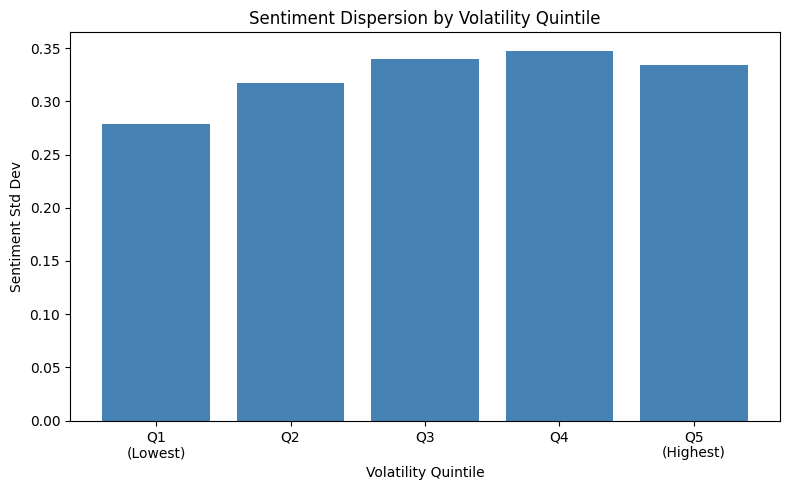

Saved: Fig_Sentiment_Dispersion.png


In [11]:
# ============================================================
# CELL 11: FIGURE 4 — Sentiment Dispersion by Volatility (MAYBE)
# ============================================================

plot_df2 = df.dropna(subset=['volatility_20d', 'sentiment']).copy()
plot_df2['vol_quintile'] = pd.qcut(plot_df2['volatility_20d'], 5, labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)'])

fig, ax = plt.subplots(figsize=(8, 5))
vol_sent_std = plot_df2.groupby('vol_quintile')['sentiment'].std()
ax.bar(vol_sent_std.index, vol_sent_std.values, color='steelblue')
ax.set_title('Sentiment Dispersion by Volatility Quintile')
ax.set_xlabel('Volatility Quintile')
ax.set_ylabel('Sentiment Std Dev')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "Fig_Sentiment_Dispersion.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig_Sentiment_Dispersion.png")

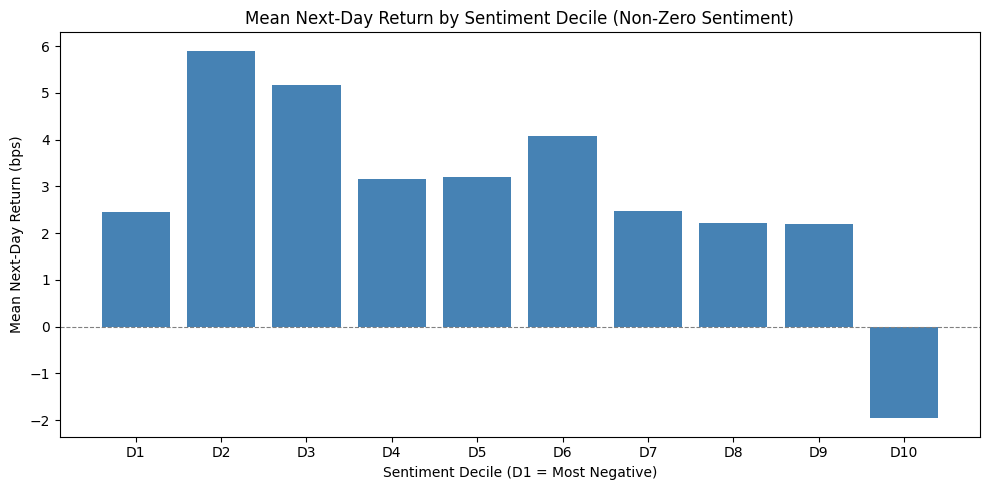

Saved: Fig_Sentiment_Return_Decile.png


In [12]:
# ============================================================
# CELL 12: FIGURE 5 — Sentiment-Return Deciles Overall (MAYBE)
# ============================================================

plot_df3 = df.dropna(subset=['next_day_return', 'sentiment']).copy()
plot_df3 = plot_df3[plot_df3['sentiment'] != 0]
plot_df3['sent_decile'] = pd.qcut(plot_df3['sentiment'], 10, labels=[f'D{i}' for i in range(1, 11)], duplicates='drop')

fig, ax = plt.subplots(figsize=(10, 5))
decile_returns = plot_df3.groupby('sent_decile')['next_day_return'].mean()
ax.bar(decile_returns.index, decile_returns.values * 10000, color='steelblue')
ax.set_title('Mean Next-Day Return by Sentiment Decile (Non-Zero Sentiment)')
ax.set_xlabel('Sentiment Decile (D1 = Most Negative)')
ax.set_ylabel('Mean Next-Day Return (bps)')
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "Fig_Sentiment_Return_Decile.png"), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Fig_Sentiment_Return_Decile.png")

In [13]:
# ============================================================
# CELL 13: Summary of All Saved Files
# ============================================================

print("\n" + "=" * 70)
print("ALL EDA OUTPUTS SAVED")
print("=" * 70)

print(f"\nFolder: {EDA_DIR}\n")
for f in sorted(os.listdir(EDA_DIR)):
    size = os.path.getsize(os.path.join(EDA_DIR, f))
    print(f"  {f} ({size:,} bytes)")

print("""
FIGURE PLACEMENT:
  Fig_Volatility_Over_Time.png      → Section 4.1 (YES — include)
  Fig_Sentiment_Coverage.png        → Section 4.1 (YES — include)
  Fig_Sentiment_Return_By_Regime.png → Section 4.1 (YES — key figure)
  Fig_Sentiment_Dispersion.png      → Section 4.1 (MAYBE — include if space)
  Fig_Sentiment_Return_Decile.png   → Section 4.1 (MAYBE — include if space)

TEXT OUTPUTS:
  descriptive_statistics.csv        → Section 4.1 (reference in prose)
  correlation_matrix.csv            → Section 4.1 (reference in prose)
  yearly_summary.csv                → Section 4.1 (can be a table)
  adf_stationarity.csv              → Section 4.1 (mention in prose)
  sector_summary.csv                → Section 4.1 (mention in prose)
""")


ALL EDA OUTPUTS SAVED

Folder: ..\..\Dissertation_Results\EDA

  Fig_Sentiment_Coverage.png (437,772 bytes)
  Fig_Sentiment_Dispersion.png (50,294 bytes)
  Fig_Sentiment_Return_By_Regime.png (72,977 bytes)
  Fig_Sentiment_Return_Decile.png (54,670 bytes)
  Fig_Volatility_Over_Time.png (123,542 bytes)
  adf_stationarity.csv (208 bytes)
  correlation_matrix.csv (392 bytes)
  descriptive_statistics.csv (364 bytes)
  sector_summary.csv (586 bytes)
  yearly_summary.csv (384 bytes)

FIGURE PLACEMENT:
  Fig_Volatility_Over_Time.png      → Section 4.1 (YES — include)
  Fig_Sentiment_Coverage.png        → Section 4.1 (YES — include)
  Fig_Sentiment_Return_By_Regime.png → Section 4.1 (YES — key figure)
  Fig_Sentiment_Dispersion.png      → Section 4.1 (MAYBE — include if space)
  Fig_Sentiment_Return_Decile.png   → Section 4.1 (MAYBE — include if space)

TEXT OUTPUTS:
  descriptive_statistics.csv        → Section 4.1 (reference in prose)
  correlation_matrix.csv            → Section 4.1 (refere